# Breast Cancer Prediction Project

Welcome to the Breast Cancer Prediction project! 🎯

In this beginner-friendly notebook, we'll walk through a step-by-step machine learning pipeline to predict whether a tumor is malignant or benign based on various features.

## 🔍 Objective

Our goal is to build a machine learning model that can accurately predict whether a tumor is **malignant (M)** or **benign (B)** based on a set of measurements.

We'll use the dataset `Cancer_Data.csv` for this purpose.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## 📥 Step 1: Load the Dataset

In [33]:

dataset = pd.read_csv('Cancer_Data[1].csv')
dataset.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## 🔍 Step 2: Explore the Dataset

In [34]:
print("Dataset Shape", dataset.shape)

Dataset Shape (569, 33)


In [13]:
print("\nMissing Values :\n ", dataset.isnull().sum())


Missing Values :
  id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_w

In [35]:
print("\nDiagnosis counts : \n ", dataset['diagnosis'].value_counts())


Diagnosis counts : 
  diagnosis
B    357
M    212
Name: count, dtype: int64


## 🧹 Step 3: Clean the Data

We'll remove any unnecessary columns and handle missing values.

In [36]:
# Drop the 'Unnamed: 32' column and 'id'
dataset = dataset.drop(columns=['Unnamed: 32', 'id'])
print(("Data Cleaned. Remaining columns : "))
print(dataset.columns)

Data Cleaned. Remaining columns : 
Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')


## 📊 Step 4: Visualize the Data

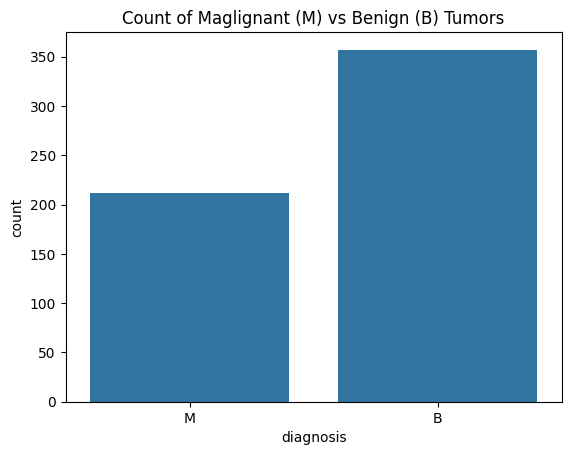

In [37]:
sns.countplot(x='diagnosis', data=dataset)
plt.title('Count of Maglignant (M) vs Benign (B) Tumors')
plt.show()

## ⚙️ Step 5: Preprocess the Data

In [38]:
# Convert diagnosis column to 0 (benign) and 1 (malignant)
dataset['diagnosis'] = dataset['diagnosis'].map({'M' : 1, 'B' : 0})

# Split features and labels
x = dataset.drop('diagnosis', axis=1)
y = dataset['diagnosis']

# Split into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


# Scale the features
saler = StandardScaler()
x_train = saler.fit_transform(x_train)
x_test = saler.transform(x_test)

print("Data Preprocessing Complete! ")
print("Training data shape :", x_train.shape)
print("Testing data shape :", x_test.shape)


Data Preprocessing Complete! 
Training data shape : (455, 30)
Testing data shape : (114, 30)


## 🤖 Step 6: Train a Machine Learning Model

In [40]:
# Use Logistic Regression
model = LogisticRegression()
model.fit(x_train, y_train)

print("Model Training Complete!")


Model Training Complete!


## 🧪 Step 7: Evaluate the Model

In [43]:
y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"MOdel Accuracy : {accuracy * 100:.2f}%\n")

print("Confusion Matrix : ")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report : ")
print(classification_report(y_test, y_pred))

MOdel Accuracy : 97.37%

Confusion Matrix : 
[[70  1]
 [ 2 41]]

Classification Report : 
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## 📊 Conclusion & Summary

We have successfully built and evaluated a **Logistic Regression** classifier to predict whether a breast tumor is Malignant or Benign.

### 🔑 Key Findings & Model Performance:
* **High Diagnostic Accuracy:** The model achieved an outstanding accuracy of **97.37%** on the unseen test dataset.
* **Precision & Recall balance:**
  * For **Benign cases (0)**, the model shows a precision of **97%** and recall of **99%**.
  * For **Malignant cases (1)**, the model achieved a precision of **98%** and recall of **95%** (only 2 false negatives out of 43 actual malignant cases), which is critical for medical diagnoses to minimize missed detections.
* **Data Preprocessing Impact:** Cleaning the dataset (removing `id` and empty columns) and applying `StandardScaler` to normalize features played a key role in ensuring stable and fast convergence of our model.

### 🚀 Future Recommendations:
1. **Alternative Classifiers:** Compare these results with non-linear models such as **Support Vector Machines (SVM)**, **Random Forests**, or **Gradient Boosting (XGBoost)**.
2. **Hyperparameter Tuning:** Use `GridSearchCV` to optimize regularization parameters (`C`, `penalty`) for Logistic Regression.
3. **Feature Importance:** Analyze feature coefficients to identify which clinical measurements are the strongest predictors of malignancy.